# EDA

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import polars as pl

local_parquet_path = "/content/drive/MyDrive/presentasi big data/talking data adtracking/hasil extract/train.parquet"

# Menggunakan scan_parquet (Lazy) agar RAM tetap hemat
# Data hanya diproses saat .collect() dipanggil
df_pq = pl.scan_parquet(local_parquet_path)

print("Contoh 1 juta data pertama (diambil secara efisien):")
display(df_pq.head(1_000_000).collect())

Contoh 1 juta data pertama (diambil secara efisien):


ip,app,device,os,channel,click_time,attributed_time,is_attributed
i64,i64,i64,i64,i64,str,str,i64
83230,3,1,13,379,"""2017-11-06 14:32:21""",null,0
17357,3,1,19,379,"""2017-11-06 14:33:34""",null,0
35810,3,1,13,379,"""2017-11-06 14:34:12""",null,0
45745,14,1,13,478,"""2017-11-06 14:34:52""",null,0
161007,3,1,13,379,"""2017-11-06 14:35:08""",null,0
…,…,…,…,…,…,…,…
29748,9,1,12,134,"""2017-11-06 16:21:51""",null,0
124520,12,1,15,178,"""2017-11-06 16:21:51""",null,0
206446,18,1,42,107,"""2017-11-06 16:21:51""",null,0


In [3]:
df_sample = df_pq.head(15_000_000).collect()

print(f"Data berhasil disimpan di variabel 'df_sample'. Jumlah baris: {len(df_sample)}")
display(df_sample)

Data berhasil disimpan di variabel 'df_sample'. Jumlah baris: 15000000


ip,app,device,os,channel,click_time,attributed_time,is_attributed
i64,i64,i64,i64,i64,str,str,i64
83230,3,1,13,379,"""2017-11-06 14:32:21""",null,0
17357,3,1,19,379,"""2017-11-06 14:33:34""",null,0
35810,3,1,13,379,"""2017-11-06 14:34:12""",null,0
45745,14,1,13,478,"""2017-11-06 14:34:52""",null,0
161007,3,1,13,379,"""2017-11-06 14:35:08""",null,0
…,…,…,…,…,…,…,…
85065,12,2,40,265,"""2017-11-07 01:37:13""",null,0
113719,3,1,31,424,"""2017-11-07 01:37:13""",null,0
43547,3,1,13,480,"""2017-11-07 01:37:13""",null,0


In [4]:
  import polars as pl

  def generate_fraud_features(df: pl.DataFrame) -> pl.DataFrame:
      """
      Mengekstrak fitur anomali bot dari log klik menggunakan Polars.
      """

      # 1. Konversi format waktu
      if df.schema.get("click_time") == pl.String:
          df = df.with_columns(
              pl.col("click_time").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S")
          )

      # 2. Pengurutan waktu
      df = df.sort("click_time")

      # 3. Pipeline Eksekusi Berantai
      df_features = (
          df.with_columns([
              pl.col("click_time").dt.hour().alias("click_hour"),
              pl.col("click_time").dt.minute().alias("click_minute"),
              pl.col("click_time").shift(1).over(["ip", "device", "os"]).alias("prev_click_time")
          ])
          .with_columns([
              # -- FITUR SEKUENSIAL --
              (pl.col("click_time") - pl.col("prev_click_time"))
                  .dt.total_seconds()
                  .fill_null(-1)
                  .alias("seconds_since_prev_click"),

              # -- FITUR DENSITAS WAKTU (KOREKSI DENGAN TRUNCATE) --
              # Total klik IP dalam blok 10 menit
              pl.col("app")
                  .count()
                  .over([pl.col("ip"), pl.col("click_time").dt.truncate("10m")])
                  .alias("ip_clicks_last_10m"),

              # Total klik perangkat (fingerprint) dalam blok 1 jam
              pl.col("app")
                  .count()
                  .over(["ip", "device", "os", pl.col("click_time").dt.truncate("1h")])
                  .alias("fingerprint_clicks_last_1h"),

              # -- FITUR DIVERSITAS --
              pl.col("channel")
                  .n_unique()
                  .over([pl.col("ip"), pl.col("click_time").dt.truncate("1h")])
                  .alias("ip_unique_channels_per_hour")
          ])
          .drop("prev_click_time")
      )

      return df_features

In [5]:
df_new=generate_fraud_features(df_sample)

In [6]:
df_new

ip,app,device,os,channel,click_time,attributed_time,is_attributed,click_hour,click_minute,seconds_since_prev_click,ip_clicks_last_10m,fingerprint_clicks_last_1h,ip_unique_channels_per_hour
i64,i64,i64,i64,i64,datetime[μs],str,i64,i8,i8,i64,u32,u32,u32
83230,3,1,13,379,2017-11-06 14:32:21,null,0,14,32,-1,1,1,1
17357,3,1,19,379,2017-11-06 14:33:34,null,0,14,33,-1,1,1,1
35810,3,1,13,379,2017-11-06 14:34:12,null,0,14,34,-1,1,1,1
45745,14,1,13,478,2017-11-06 14:34:52,null,0,14,34,-1,1,1,1
161007,3,1,13,379,2017-11-06 14:35:08,null,0,14,35,-1,1,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…
85065,12,2,40,265,2017-11-07 01:37:13,null,0,1,37,8766,13,1,49
113719,3,1,31,424,2017-11-07 01:37:13,null,0,1,37,9,34,5,52
43547,3,1,13,480,2017-11-07 01:37:13,null,0,1,37,1381,11,4,19


In [7]:
# Menghitung statistik deskriptif: mean, std, min, q1, median, q3, max
display(df_new.describe())

statistic,ip,app,device,os,channel,click_time,attributed_time,is_attributed,click_hour,click_minute,seconds_since_prev_click,ip_clicks_last_10m,fingerprint_clicks_last_1h,ip_unique_channels_per_hour
str,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""",1.5e7,1.5e7,1.5e7,1.5e7,1.5e7,"""15000000""","""32060""",1.5e7,1.5e7,1.5e7,1.5e7,1.5e7,1.5e7,1.5e7
"""null_count""",0.0,0.0,0.0,0.0,0.0,"""0""","""14967940""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",87149.582699,12.567688,32.438879,24.409011,255.762945,"""2017-11-06 21:47:53.099988""",null,0.002137,12.219843,27.825202,506.452399,83.069943,67.837706,39.972828
"""std""",55733.859004,16.297672,306.066491,60.995667,128.474159,null,null,0.046182,9.541527,17.080055,2598.525485,231.702562,216.251594,24.393246
"""min""",9.0,0.0,0.0,0.0,0.0,"""2017-11-06 14:32:21""","""2017-11-06 16:00:47""",0.0,0.0,0.0,-1.0,1.0,1.0,1.0
"""25%""",41822.0,3.0,1.0,13.0,135.0,"""2017-11-06 18:11:57""",null,0.0,1.0,13.0,0.0,13.0,9.0,20.0
"""50%""",81792.0,12.0,1.0,18.0,245.0,"""2017-11-06 23:16:56""",null,0.0,16.0,27.0,3.0,25.0,21.0,37.0
"""75%""",121278.0,15.0,1.0,19.0,371.0,"""2017-11-07 00:32:25""",null,0.0,21.0,42.0,37.0,54.0,48.0,57.0
"""max""",212774.0,675.0,3545.0,745.0,498.0,"""2017-11-07 01:37:13""","""2017-11-07 15:59:53""",1.0,23.0,59.0,35970.0,3299.0,4161.0,117.0


In [8]:
import polars as pl

# Menghitung baris dengan clicks > 5 dan > 10
count_gt_5 = df_new.filter(pl.col("ip_clicks_last_10m") > 5).height
count_gt_10 = df_new.filter(pl.col("ip_clicks_last_10m") > 10).height

print(f"Jumlah baris dengan ip_clicks_last_10m > 5: {count_gt_5:,}")
print(f"Jumlah baris dengan ip_clicks_last_10m > 10: {count_gt_10:,}")

# Menampilkan persentase dari total data
total_rows = len(df_new)
print(f"\nPersentase (> 5): {(count_gt_5 / total_rows * 100):.2f}%")
print(f"Persentase (> 10): {(count_gt_10 / total_rows * 100):.2f}%")

Jumlah baris dengan ip_clicks_last_10m > 5: 13,531,515
Jumlah baris dengan ip_clicks_last_10m > 10: 11,896,863

Persentase (> 5): 90.21%
Persentase (> 10): 79.31%


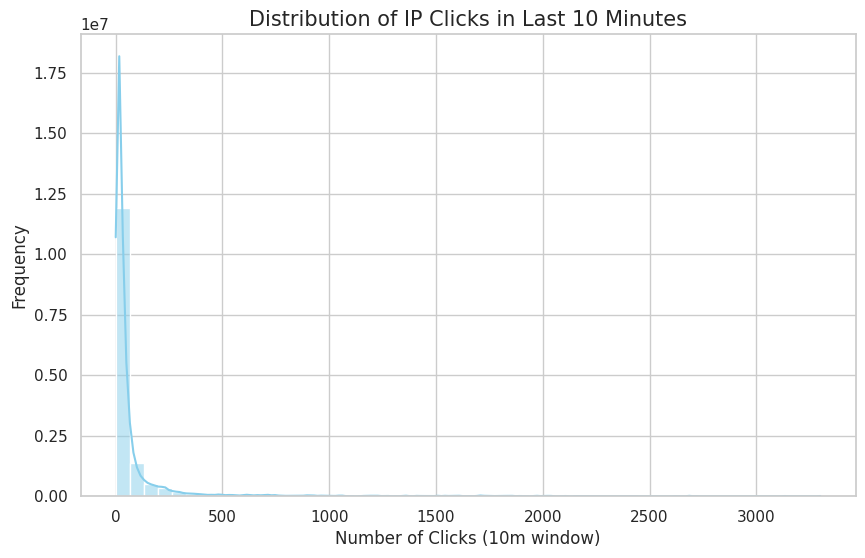

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot histogram for ip_clicks_last_10m tanpa log scale
sns.histplot(df_new["ip_clicks_last_10m"].to_pandas(), bins=50, kde=True, color='skyblue')

plt.title("Distribution of IP Clicks in Last 10 Minutes", fontsize=15)
plt.xlabel("Number of Clicks (10m window)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

### Distribution of `seconds_since_prev_click`

This feature represents the time difference between consecutive clicks from the same `(ip, device, os)` combination. Very small values (near 0) or values equal to -1 (for the first click) could indicate bot-like behavior or a user clicking very rapidly.

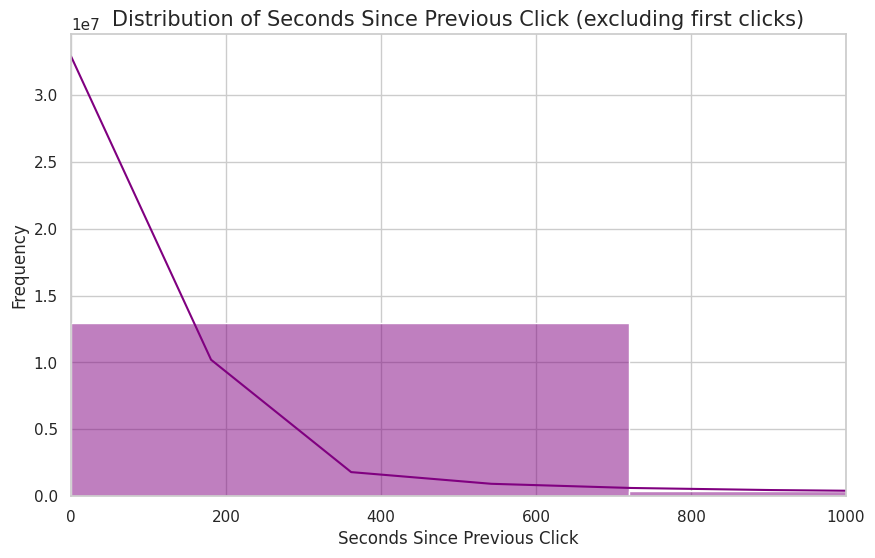

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df_new.filter(pl.col("seconds_since_prev_click") >= 0)['seconds_since_prev_click'].to_pandas(), bins=50, kde=True, color='purple')
plt.title("Distribution of Seconds Since Previous Click (excluding first clicks)", fontsize=15)
plt.xlabel("Seconds Since Previous Click", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xlim(0, 1000) # Focusing on the lower range for better visibility of rapid clicks
plt.show()

### Distribution of `fingerprint_clicks_last_1h`

This feature counts the number of clicks from the same `(ip, device, os)` combination within a 1-hour window. High values could indicate suspicious activity from a specific device fingerprint.

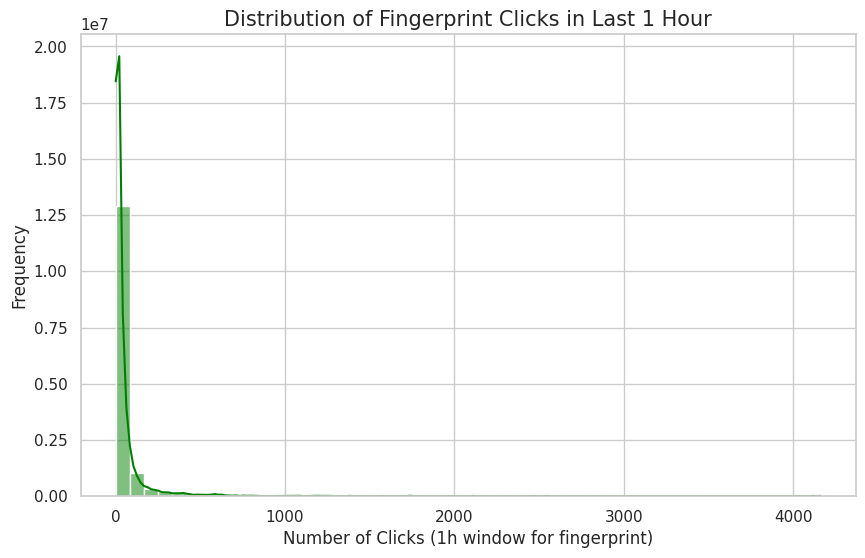

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df_new['fingerprint_clicks_last_1h'].to_pandas(), bins=50, kde=True, color='green')
plt.title("Distribution of Fingerprint Clicks in Last 1 Hour", fontsize=15)
plt.xlabel("Number of Clicks (1h window for fingerprint)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

### Distribution of `ip_unique_channels_per_hour`

This feature measures the diversity of channels used by a specific IP address within a 1-hour window. A very high number of unique channels from a single IP might suggest bot activity or a compromised IP.

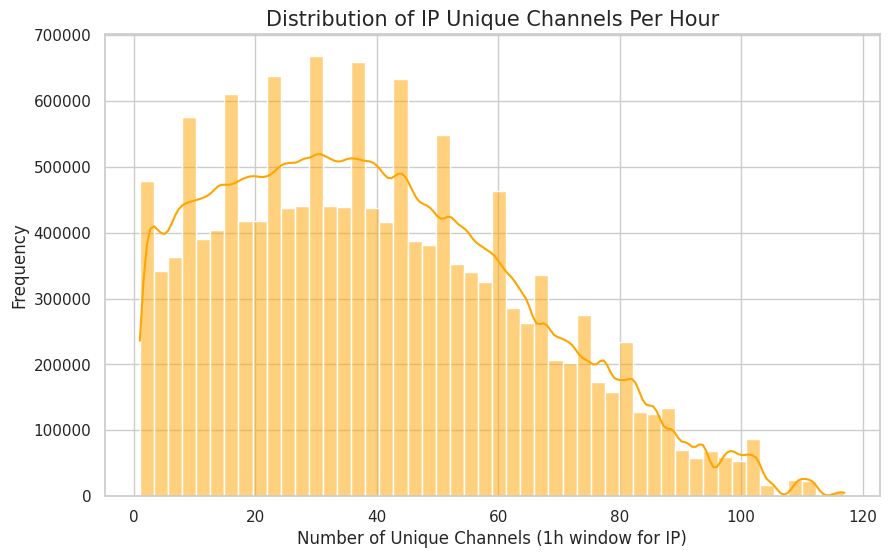

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df_new['ip_unique_channels_per_hour'].to_pandas(), bins=50, kde=True, color='orange')
plt.title("Distribution of IP Unique Channels Per Hour", fontsize=15)
plt.xlabel("Number of Unique Channels (1h window for IP)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

## Model Training and Evaluation

In [13]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Ensure 'is_attributed' is aligned with df_new's rows.
# We assume df_new was created from df_sample, so row order should be maintained.
X = df_new.drop(['click_time', 'attributed_time'])
y = df_sample['is_attributed']

# Convert Polars DataFrame to Pandas for scikit-learn compatibility
X_pd = X.to_pandas()
y_pd = y.to_pandas()

# Split data into training and testing sets
# Using stratify=y to ensure the proportion of target classes is maintained in both train and test sets,
# which is crucial for imbalanced datasets like fraud detection.
X_train, X_test, y_train, y_test = train_test_split(
    X_pd, y_pd, test_size=0.3, random_state=42, stratify=y_pd
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of 'is_attributed' in original data:")
print(y_pd.value_counts(normalize=True))

print("\nDistribution of 'is_attributed' in training set:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of 'is_attributed' in testing set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (10500000, 12)
Shape of X_test: (4500000, 12)
Shape of y_train: (10500000,)
Shape of y_test: (4500000,)

Distribution of 'is_attributed' in original data:
is_attributed
0    0.997863
1    0.002137
Name: proportion, dtype: float64

Distribution of 'is_attributed' in training set:
is_attributed
0    0.997863
1    0.002137
Name: proportion, dtype: float64

Distribution of 'is_attributed' in testing set:
is_attributed
0    0.997863
1    0.002137
Name: proportion, dtype: float64


Sekarang data sudah dibagi menjadi set pelatihan dan pengujian. Selanjutnya, mari kita coba melatih beberapa model klasifikasi dan membandingkan performanya.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum())
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probability of positive class

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, ROC AUC: {roc_auc:.4f}")

# Display all results in a DataFrame for easy comparison
import pandas as pd
results_df = pd.DataFrame(results).T
display(results_df.sort_values(by='ROC AUC', ascending=False))


Training Logistic Regression...
Logistic Regression - Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000, ROC AUC: 1.0000

Training Random Forest...
